In [ ]:
# Este bloque detecta que estás en una TPU y te prepara la memoria
import os
os.environ['XLA_USE_BF16'] = '1' # Optimiza el uso de memoria a 16 bits

import torch
# Si vas a usar PyTorch (como en el notebook de Grafos), esto activa la TPU:
# import torch_xla.core.xla_model as xm
# device = xm.xla_device()

AUTOENCODER

In [ ]:
# Instala tensorflow y luego ejecuta el resto
!pip install tensorflow -q

In [ ]:
# ==============================================================================
# PASO 1: IMPORTAR LIBRERÍAS Y CARGAR DATOS
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Conectar al Drive
from google.colab import drive
drive.mount('/content/drive')

print("🚀 1. Cargando la matriz matemática limpia...")
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'
df = pd.read_csv(ruta_datos)

# ==============================================================================
# PASO 1.5: 🛡️ REPARACIÓN DE CORTOCIRCUITOS MATEMÁTICOS (NaNs e Infs)
# ==============================================================================
print("\n🛠️ Buscando 'cortocircuitos' (valores vacíos o infinitos)...")
nulos_totales = df.isnull().sum().sum()
print(f"⚠️ Se encontraron {nulos_totales} valores vacíos (NaN) ocultos en la matriz.")

# Rellenamos los vacíos con 0 y los infinitos con 0 para que la red neuronal no colapse
df = df.fillna(0)
df = df.replace([np.inf, -np.inf], 0)
print("✅ Aislamiento aplicado. Matriz 100% numérica y segura.")

# ==============================================================================
# PASO 2: SEPARAR EL FRAUDE Y ESCALAR LA "SEÑAL"
# ==============================================================================
print("\n⚙️ 2. Separando variables (X) del objetivo (Y)...")

col_objetivo =[c for c in df.columns if 'FRAUDE_IA' in c][0]
Y = df[col_objetivo].values
X = df.drop(columns=[col_objetivo]).values

print("📏 3. Escalando los datos (Normalización entre 0 y 1)...")
scaler = MinMaxScaler()
X_escalado = scaler.fit_transform(X)

# ==============================================================================
# PASO 3: CREAR EL CONJUNTO DE ENTRENAMIENTO "SANO"
# ==============================================================================
print("\n🔬 4. Aislando el comportamiento 'Normal' para enseñar al Autoencoder...")
X_normal = X_escalado[Y == 0]
X_fraude = X_escalado[Y == 1]

X_train_normal, X_val_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

print(f"✅ Transacciones NORMALES para entrenamiento: {X_train_normal.shape[0]}")
print(f"✅ Transacciones NORMALES para validación: {X_val_normal.shape[0]}")
print(f"🚨 Transacciones de FRAUDE reservadas: {X_fraude.shape[0]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 1. Cargando la matriz matemática limpia...


In [ ]:
# ==============================================================================
# PASO 4: ARQUITECTURA DEL AUTOENCODER (DEEP LEARNING)
# ==============================================================================
print("🏗️ 1. Construyendo la arquitectura de la Red Neuronal (Autoencoder)...")

from tensorflow.keras.callbacks import EarlyStopping

# Cuántas variables entran (Deberían ser 290, ya que quitamos 1 que es el FRAUDE_IA)
input_dim = X_train_normal.shape[1]

# --- A. EL ENCODER (Transformador Reductor) ---
# Capa de entrada
input_layer = Input(shape=(input_dim,), name="Entrada_290_Variables")

# Capas ocultas de compresión (Reduciendo la dimensionalidad)
encoded = Dense(128, activation='relu', name="Compresion_128")(input_layer)
encoded = Dense(64, activation='relu', name="Compresion_64")(encoded)
encoded = Dense(32, activation='relu', name="Cuello_de_Botella_32")(encoded) # El núcleo

# --- B. EL DECODER (Transformador Elevador) ---
# Capas ocultas de reconstrucción
decoded = Dense(64, activation='relu', name="Reconstruccion_64")(encoded)
decoded = Dense(128, activation='relu', name="Reconstruccion_128")(decoded)

# Capa de salida (Debe tener el mismo tamaño que la entrada: 290)
# Usamos 'sigmoid' porque nuestros datos están escalados entre 0 y 1
output_layer = Dense(input_dim, activation='sigmoid', name="Salida_Reconstruida")(decoded)

# --- C. ENSAMBLAJE Y COMPILACIÓN DEL MODELO ---
# Unimos la entrada y la salida en un solo modelo
autoencoder = Model(inputs=input_layer, outputs=output_layer, name="Autoencoder_Fraude")

# Usamos el optimizador 'adam' (muy eficiente) y medimos el Error Cuadrático Medio (MSE)
autoencoder.compile(optimizer='adam', loss='mse')

# Mostramos el resumen de nuestra creación
print("\n✅ Arquitectura lista. Resumen del modelo:")
autoencoder.summary()

# ==============================================================================
# PASO 5: ENTRENAMIENTO DE LA RED NEURONAL
# ==============================================================================
print("\n🧠 2. Iniciando el entrenamiento con transacciones NORMALES...")

# Breaker de seguridad: "Early Stopping"
# Si la red deja de aprender (no mejora en 5 iteraciones), se detiene para no sobreajustarse.
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# ¡A ENTRENAR! (fit)
# Fíjate que la entrada (X) y la salida esperada (Y) son la misma: X_train_normal
historia = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,             # Número máximo de vueltas al dataset
    batch_size=256,        # Transacciones que procesa al mismo tiempo (paquetes)
    validation_data=(X_val_normal, X_val_normal), # Datos para examen
    callbacks=[early_stopping], # Nuestro breaker de seguridad
    verbose=1
)

# ==============================================================================
# PASO 6: GRAFICAR EL APRENDIZAJE
# ==============================================================================
print("\n📊 3. Graficando la curva de aprendizaje (Error de reconstrucción)...")

plt.figure(figsize=(10, 6))
plt.plot(historia.history['loss'], label='Error de Entrenamiento (Train Loss)', color='blue')
plt.plot(historia.history['val_loss'], label='Error de Validación (Val Loss)', color='orange')
plt.title('Curva de Aprendizaje del Autoencoder')
plt.xlabel('Épocas (Vueltas de entrenamiento)')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

print("✅ Entrenamiento finalizado. La red neuronal ha aprendido el patrón 'Normal'.")

In [ ]:
# ==============================================================================
# PASO 7: RECONSTRUCCIÓN Y CÁLCULO DE ERRORES (LA PRUEBA DE FUEGO)
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, f1_score, recall_score, matthews_corrcoef, confusion_matrix
import seaborn as sns

print("🔍 1. Pasando datos normales y FRAUDES por el Autoencoder...")

# Le pedimos a la red neuronal que intente reconstruir los datos
reconstruccion_normal = autoencoder.predict(X_val_normal)
reconstruccion_fraude = autoencoder.predict(X_fraude)

# Calculamos el Error Cuadrático Medio (MSE) por cada transacción
# Matemáticamente: (Entrada - Salida_Reconstruida)^2
mse_normal = np.mean(np.power(X_val_normal - reconstruccion_normal, 2), axis=1)
mse_fraude = np.mean(np.power(X_fraude - reconstruccion_fraude, 2), axis=1)

# ==============================================================================
# PASO 8: DEFINIR EL UMBRAL (EL RELÉ DE PROTECCIÓN)
# ==============================================================================
print("\n⚡ 2. Ajustando el relé de protección (Umbral)...")
# Establecemos el umbral en el percentil 95 de los errores normales.
# Significa que toleramos un 5% de falsos positivos teóricos para atrapar los fraudes.
umbral = np.percentile(mse_normal, 95)
print(f"✅ Umbral de disparo establecido en MSE = {umbral:.6f}")

# ==============================================================================
# PASO 9: VISUALIZACIÓN DE LA SEPARACIÓN (PARA EL DOCUMENTO)
# ==============================================================================
print("\n📊 3. Graficando la diferencia de errores (Normal vs Fraude)...")
plt.figure(figsize=(10,6))
# Usamos una escala logarítmica porque hay muchos más normales que fraudes
plt.hist(mse_normal, bins=50, alpha=0.6, color='blue', label='Transacciones Normales')
plt.hist(mse_fraude, bins=50, alpha=0.6, color='red', label='FRAUDES')
plt.axvline(umbral, color='orange', linestyle='dashed', linewidth=2, label=f'Umbral (Alarma) = {umbral:.6f}')
plt.title('Distribución del Error de Reconstrucción (Autoencoder)')
plt.xlabel('Error (MSE)')
plt.ylabel('Cantidad de Transacciones (Escala Logarítmica)')
plt.yscale('log')
plt.legend()
plt.show()

# ==============================================================================
# PASO 10: EVALUACIÓN Y MÉTRICAS (LO QUE PIDIÓ EL JURADO)
# ==============================================================================
print("\n📈 4. Calculando las métricas de desempeño para el documento...")

# Unimos los datos para la prueba final evaluativa
y_true = np.append(np.zeros(len(mse_normal)), np.ones(len(mse_fraude)))
mse_total = np.append(mse_normal, mse_fraude)

# Si el error supera el umbral, el algoritmo dice que es Fraude (1), si no, Normal (0)
y_pred = (mse_total > umbral).astype(int)

# Calculamos AUPRC (Área bajo la curva Precision-Recall - La que prometiste en el anteproyecto)
precision, recall, _ = precision_recall_curve(y_true, mse_total)
auprc = auc(recall, precision)

# Calculamos las demás métricas
f1 = f1_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred) # La métrica reina para desbalanceados

print("-" * 50)
print("🏆 RESULTADOS FINALES DEL AUTOENCODER:")
print("-" * 50)
print(f"🔸 AUPRC (Métrica Prioritaria): {auprc:.4f}")
print(f"🔸 Recall (Fraudes reales detectados): {rec:.2%}")
print(f"🔸 F1-Score: {f1:.4f}")
print(f"🔸 Coeficiente de Matthews (MCC): {mcc:.4f}  <-- ¡Nueva métrica recomendada!")
print("-" * 50)

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
print("\n🚨 IMPACTO EN EL NEGOCIO (Matriz de Confusión):")
print(f"✔️ Clientes sanos que pasaron sin problema: {cm[0][0]}")
print(f"⚠️ Falsos Positivos (Clientes sanos molestados): {cm[0][1]}")
print(f"❌ Falsos Negativos (Fraudes que se nos escaparon): {cm[1][0]}")
print(f"🎯 FRAUDES DETECTADOS Y BLOQUEADOS: {cm[1][1]}")

XGBOOST

In [ ]:
!pip install xgboost scikit-plot -q

# ==============================================================================
# PASO 1 y 2: CARGA Y PREPARACIÓN DE BIG DATA (XGBOOST - ULTRA LIGERO)
# ==============================================================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, auc, f1_score, recall_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from google.colab import drive

drive.mount('/content/drive')

print("🚀 1. Cargando matriz gigante optimizando RAM al máximo...")
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'

# TRUCO 1: Usar engine='pyarrow' hace que pandas use mucha menos RAM al leer
df = pd.read_csv(ruta_datos, engine='pyarrow')

# Compresión de tipos de datos
for col in df.columns:
    if df[col].dtype == 'float64': df[col] = df[col].astype('float32')
    elif df[col].dtype == 'int64': df[col] = df[col].astype('int32')

col_objetivo = [c for c in df.columns if 'FRAUDE_IA' in c][0]

# TRUCO 2: .pop() extrae la columna y la borra del df original ¡Sin hacer copias extra!
Y = df.pop(col_objetivo).values
X = df.values

# Liberar el DataFrame gigante de inmediato
del df
gc.collect()
print("🧹 Primera limpieza de memoria exitosa.")

print("\n⚙️ 2. Particionando el dataset (80% Train / 20% Test)...")
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# TRUCO 3: Como ya tenemos Train y Test, destruimos la X y Y originales para liberar más RAM
del X, Y
gc.collect()
print(f"   🔸 Entrenando con: {X_train.shape[0]} transacciones.")
print(f"   🔸 Evaluando con: {X_test.shape[0]} transacciones.")
print("🧹 Segunda limpieza de memoria exitosa.")

# ==============================================================================
# PASO 3: ENTRENAMIENTO DEL CAZADOR (XGBOOST)
# ==============================================================================
print("\n⚖️ 3. Ajustando pesos por desbalanceo...")
peso_fraude = np.sum(y_train == 0) / np.sum(y_train == 1)

modelo_xgb = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=peso_fraude,
    tree_method='hist', # Vital para Big Data
    random_state=42,
    n_jobs=-1
)

print("\n🧠 4. Entrenando el modelo XGBoost (Esto tomará 1-3 minutos)...")
modelo_xgb.fit(X_train, y_train)
print("✅ ¡Entrenamiento completado!")

# ==============================================================================
# PASO 4: EVALUACIÓN Y RESULTADOS FINALES
# ==============================================================================
print("\n🎯 5. Realizando predicciones sobre el 20% de datos invisibles...")
y_pred = modelo_xgb.predict(X_test)
y_prob = modelo_xgb.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)
auprc = auc(recall, precision)

print("-" * 50)
print("🏆 RESULTADOS FINALES DE XGBOOST (BIG DATA):")
print("-" * 50)
print(f"🔸 AUPRC (Métrica Prioritaria): {auprc:.4f}")
print(f"🔸 Recall (Fraudes detectados): {recall_score(y_test, y_pred):.2%}")
print(f"🔸 F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"🔸 Coeficiente de Matthews (MCC): {matthews_corrcoef(y_test, y_pred):.4f}")
print("-" * 50)

cm = confusion_matrix(y_test, y_pred)
print("\n🚨 IMPACTO EN EL NEGOCIO (En el 20% de prueba):")
print(f"✔️ Clientes sanos permitidos: {cm[0][0]}")
print(f"⚠️ Falsos Positivos (Bloqueados por error): {cm[0][1]}")
print(f"❌ Falsos Negativos (Se nos escaparon): {cm[1][0]}")
print(f"🎯 FRAUDES DETECTADOS Y BLOQUEADOS: {cm[1][1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 1. Cargando matriz gigante optimizando RAM al máximo...
🧹 Primera limpieza de memoria exitosa.

⚙️ 2. Particionando el dataset (80% Train / 20% Test)...
   🔸 Entrenando con: 1178348 transacciones.
   🔸 Evaluando con: 294587 transacciones.
🧹 Segunda limpieza de memoria exitosa.

⚖️ 3. Ajustando pesos por desbalanceo...

🧠 4. Entrenando el modelo XGBoost (Esto tomará 1-3 minutos)...
✅ ¡Entrenamiento completado!

🎯 5. Realizando predicciones sobre el 20% de datos invisibles...
--------------------------------------------------
🏆 RESULTADOS FINALES DE XGBOOST (BIG DATA):
--------------------------------------------------
🔸 AUPRC (Métrica Prioritaria): 0.5944
🔸 Recall (Fraudes detectados): 91.80%
🔸 F1-Score: 0.1028
🔸 Coeficiente de Matthews (MCC): 0.2213
--------------------------------------------------

🚨 IMPACTO EN EL NEGOCIO (En el 20% de prueba):
✔️ Cliente

SHARP

In [ ]:
# ==============================================================================
# BLOQUE MAESTRO: ENTRENAMIENTO Y RADIOGRAFÍA SHAP (TODO EN UNO)
# ==============================================================================
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Conectar y Cargar
drive.mount('/content/drive')
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_limpio_IA.csv'
df = pd.read_csv(ruta_datos)

# 2. Preparar datos
col_objetivo = 'FRAUDE_IA'
X = df.drop(columns=[col_objetivo]).values
Y = df[col_objetivo].values
nombres_variables = df.drop(columns=[col_objetivo]).columns.tolist()

# 3. Entrenar el Cazador (XGBoost rápido)
print("🧠 Entrenando modelo de respaldo para SHAP...")
peso_fraude = np.sum(Y == 0) / np.sum(Y == 1)
modelo_xgb = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=peso_fraude, tree_method='hist', n_jobs=-1)
modelo_xgb.fit(X, Y)
print("✅ ¡Modelo listo!")

# 4. Calcular el Osciloscopio SHAP
print("⏳ Calculando impacto SHAP (esto puede tardar 1-2 minutos)...")
# Tomamos una muestra para que el cálculo sea rápido
np.random.seed(42)
indices_muestra = np.random.choice(X.shape[0], size=1000, replace=False)
X_muestra = X[indices_muestra]
df_muestra_shap = pd.DataFrame(X_muestra, columns=nombres_variables)

explicador = shap.TreeExplainer(modelo_xgb)
shap_values = explicador(df_muestra_shap)

# 5. Generar Radiografía Global
print("📊 Generando Radiografía...")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, df_muestra_shap, max_display=20, show=False)
plt.title("Radiografía del Fraude: Top 20 Variables Críticas (SHAP)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# NOTEBOOK 5: REDES NEURONALES DE GRAFOS (GNN) - VERSION FINAL
# ==============================================================================
!pip install torch torch-geometric -q

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Carga de datos
drive.mount('/content/drive')
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'
df = pd.read_csv(ruta_datos)

# 2. Selección de columnas para el Grafo (Variables numéricas de comportamiento)
# Usamos solo variables clave para no saturar la memoria
cols_clave = [c for c in df.columns if 'FRAUDE_IA' not in c and df[c].dtype in ['int64', 'int32', 'float32', 'float64']]
cols_finales = cols_clave[:30] # Tomamos las primeras 30 numéricas
print(f"✅ Variables seleccionadas para el Grafo: {len(cols_finales)}")

# 3. Preparar tensores (X e Y)
X_final = torch.tensor(df[cols_finales].fillna(0).values, dtype=torch.float)
Y_final = torch.tensor(df['FRAUDE_IA'].values, dtype=torch.long)

# 4. Crear Grafo (Topología por similitud de transacciones)
# Para evitar errores de memoria, conectamos nodos en cadena (Line Graph)
num_nodos = X_final.shape[0]
edge_index = torch.stack([
    torch.arange(num_nodos - 1),
    torch.arange(1, num_nodos)
], dim=0)

data = Data(x=X_final, edge_index=edge_index, y=Y_final)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

# 5. Definir Modelo GCN Robusto
class RobustGCN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RobustGCN, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.tanh(x) # Estabilidad numérica
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = RobustGCN(num_features=data.x.shape[1], num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 6. Entrenamiento con Máscaras (Validación 80/20)
print("\n🚀 Entrenando GNN con validación 80/20...")
indices = np.arange(num_nodos)
train_idx = indices[:int(0.8 * num_nodos)]
test_idx = indices[int(0.8 * num_nodos):]

train_mask = torch.zeros(num_nodos, dtype=torch.bool)
test_mask = torch.zeros(num_nodos, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

model.train()
for epoch in range(50):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"   Época {epoch+1} | Loss: {loss.item():.4f}")

# 7. Evaluación
model.eval()
_, pred = model(data.x, data.edge_index).max(dim=1)
acc_test = (pred[test_mask].eq(data.y[test_mask]).sum().item()) / test_mask.sum().item()
print(f"\n🎯 Precisión final de la GNN en validación (20%): {acc_test:.2%}")

In [ ]:
total_muestras = data.y.size(0)
num_fraudes = torch.sum(data.y == 1).item()
num_normales = total_muestras - num_fraudes

# Peso para la clase Fraude: normal/fraude
weight_fraude = num_normales / num_fraudes
weights = torch.tensor([1.0, weight_fraude], device=device)

# 2. Re-entrenar con pesos (nll_loss recibe el weight)
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    # Aplicamos el peso aquí:
    loss = F.nll_loss(out[train_mask], data.y[train_mask], weight=weights)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"   Época {epoch+1} | Loss con pesos: {loss.item():.4f}")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Obtener predicciones del test_mask
y_true_gnn = data.y[test_mask].cpu().numpy()
y_pred_gnn = pred[test_mask].cpu().numpy()

print("\n🚨 IMPACTO REAL (Matriz de Confusión GNN - Datos Invisibles):")
print(confusion_matrix(y_true_gnn, y_pred_gnn))

print("\n🏆 INFORME DETALLADO:")
print(classification_report(y_true_gnn, y_pred_gnn, target_names=['Normal', 'Fraude']))

DRL

In [ ]:
# ==============================================================================
# PASO 1: CARGA, LIMPIEZA ABSOLUTA DE NaNs Y PREPARACIÓN DRL
# ==============================================================================
!pip install gymnasium stable-baselines3 shimmy -q
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, auc, f1_score, recall_score, matthews_corrcoef, confusion_matrix
import gc
from google.colab import drive

drive.mount('/content/drive')

print("🚀 1. Leyendo datos por fragmentos (Chunking)...")
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'

lista_final =[]
for chunk in pd.read_csv(ruta_datos, chunksize=50000):
    col_obj =[c for c in chunk.columns if 'FRAUDE_IA' in c][0]

    for col in chunk.columns:
        if chunk[col].dtype == 'float64': chunk[col] = chunk[col].astype('float32')
        elif chunk[col].dtype == 'int64': chunk[col] = chunk[col].astype('int8')

    fraudes = chunk[chunk[col_obj] == 1]
    sanos = chunk[chunk[col_obj] == 0].sample(frac=0.05, random_state=42)

    lista_final.append(pd.concat([fraudes, sanos]))
    del chunk, fraudes, sanos
    gc.collect()

df = pd.concat(lista_final, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
del lista_final
gc.collect()

print(f"   ✅ Dataset extraído: {len(df)} transacciones.")

# ------------------------------------------------------------------------------
print("\n⚙️ 2. Protegiendo matrices, Particionando y Escalando...")
Y = df.pop(col_obj).values.astype(np.int8)
X = df.values.astype(np.float32)

# --- ¡EL ESCUDO PROTECTOR ANTI-NaNs! ---
# Convertimos cualquier NaN o Infinito oculto en ceros matemáticos seguros
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

del X, Y, df
gc.collect()

# ==============================================================================
# PASO 2: CREACIÓN DEL ENTORNO BANCARIO (NATURAL)
# ==============================================================================
print("\n🏦 3. Construyendo el Entorno de Simulacion Bancaria (Natural)...")

class EntornoBanco(gym.Env):
    def __init__(self, X_data, Y_data):
        super(EntornoBanco, self).__init__()
        self.X_data = X_data
        self.Y_data = Y_data
        self.action_space = spaces.Discrete(3) # 0: Permitir, 1: Bloquear, 2: OTP
        self.observation_space = spaces.Box(low=0, high=1, shape=(X_data.shape[1],), dtype=np.float32)
        self.current_step = 0

    def step(self, action):
        is_fraud = self.Y_data[self.current_step]

        if is_fraud == 1:
            if action == 1: reward = 10
            elif action == 2: reward = 5
            else: reward = -100
        else:
            if action == 0: reward = 1
            elif action == 2: reward = -2
            else: reward = -10

        self.current_step += 1
        done = self.current_step >= len(self.X_data) - 1
        obs = self.X_data[self.current_step] if not done else self.X_data[0]
        return obs, reward, done, False, {}

    def reset(self, seed=None):
        self.current_step = 0
        return self.X_data[0], {}

env_train = EntornoBanco(X_train_scaled, y_train)

# ==============================================================================
# PASO 3: ENTRENAMIENTO DEL AGENTE PPO
# ==============================================================================
print(f"\n🧠 4. Entrenando al Supervisor Inteligente PPO...")
model_drl = PPO("MlpPolicy", env_train, verbose=0, learning_rate=0.0005)
model_drl.learn(total_timesteps=50000)
print("✅ ¡Entrenamiento completado sin fallos!")

# ==============================================================================
# PASO 4: EVALUACIÓN MASIVA
# ==============================================================================
print("\n🎯 5. Evaluando al Agente sobre el 20% de prueba...")

acciones_drl =[]
lote = 5000
for i in range(0, len(X_test_scaled), lote):
    X_lote = X_test_scaled[i:i+lote]
    acc, _ = model_drl.predict(X_lote, deterministic=True)
    acciones_drl.append(acc)

acciones_drl = np.concatenate(acciones_drl)
y_pred_drl = (acciones_drl > 0).astype(int)

precision_drl, recall_curv_drl, _ = precision_recall_curve(y_test, y_pred_drl)
auprc_drl = auc(recall_curv_drl, precision_drl)

print("-" * 50)
print("🏆 RESULTADOS FINALES DE DRL (ENTORNO NATURAL):")
print("-" * 50)
print(f"🔸 AUPRC: {auprc_drl:.4f}")
print(f"🔸 Recall (Fraudes mitigados): {recall_score(y_test, y_pred_drl):.2%}")
print(f"🔸 F1-Score: {f1_score(y_test, y_pred_drl):.4f}")
print(f"🔸 MCC: {matthews_corrcoef(y_test, y_pred_drl):.4f}")
print("-" * 50)

cm_drl = confusion_matrix(y_test, y_pred_drl)
print("\n🚨 IMPACTO EN EL NEGOCIO (DRL):")
print(f"✔️ Clientes sanos permitidos: {cm_drl[0][0]}")
print(f"⚠️ Falsos Positivos (Clientes con OTP/Bloqueo): {cm_drl[0][1]}")
print(f"❌ Falsos Negativos (Fraudes que pasaron): {cm_drl[1][0]}")
print(f"🎯 FRAUDES DETECTADOS (Bloqueo o OTP): {cm_drl[1][1]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 14.6 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Mounted at /content/drive
🚀 1. Leyendo datos por fragmentos (Chunking)...
   ✅ Dataset extraído: 75153 transacciones.

⚙️ 2. Protegiendo matrices, Particionando y Escalando...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



🏦 3. Construyendo el Entorno de Simulacion Bancaria (Natural)...

🧠 4. Entrenando al Supervisor Inteligente PPO...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ ¡Entrenamiento completado sin fallos!

🎯 5. Evaluando al Agente sobre el 20% de prueba...
--------------------------------------------------
🏆 RESULTADOS FINALES DE DRL (ENTORNO NATURAL):
--------------------------------------------------
🔸 AUPRC: 0.5890
🔸 Recall (Fraudes mitigados): 86.12%
🔸 F1-Score: 0.4600
🔸 MCC: 0.5049
--------------------------------------------------

🚨 IMPACTO EN EL NEGOCIO (DRL):
✔️ Clientes sanos permitidos: 14117
⚠️ Falsos Positivos (Clientes con OTP/Bloqueo): 597
❌ Falsos Negativos (Fraudes que pasaron): 44
🎯 FRAUDES DETECTADOS (Bloqueo o OTP): 273


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Entrenamos el modelo...
model_drl = PPO("MlpPolicy", env_train, verbose=1, learning_rate=0.0005)
model_drl.learn(total_timesteps=50000)

# ¡IMPORTANTE! Guardamos el cerebro entrenado en tu carpeta de Drive
model_drl.save("/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/drl_modelo_final")
print("✅ Modelo entrenado y guardado en Drive.")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 411  |
|    iterations      | 1    |
|    time_elapsed    | 4    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 277         |
|    iterations           | 2           |
|    time_elapsed         | 14          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013452782 |
|    clip_fraction        | 0.22        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | 0.00122     |
|    learning_rate        | 0.0005      |
|    loss                 | 1.91e+03    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0222     |
|    value_loss         

In [ ]:
# ==============================================================================
# AUDITORÍA FINAL DRL: EVALUACIÓN ANTI-RAM (Muestreo Destructivo)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from sklearn.metrics import recall_score, f1_score, matthews_corrcoef, confusion_matrix
import gc
from google.colab import drive

# 1. CONEXIÓN
drive.mount('/content/drive')
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'
ruta_modelo = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/drl_modelo_final'

print("🚀 1. Cargando y aislando el 20% de prueba inmediatamente...")

# Cargamos el archivo usando PyArrow (Más eficiente en RAM)
df_gigante = pd.read_csv(ruta_datos, engine='pyarrow')

# ¡TRUCO NINJA!: Sacamos el 20% exacto de los datos y destruimos el resto al instante
df_test = df_gigante.sample(frac=0.2, random_state=42)

# Liberamos la RAM del monstruo de 1.47 Millones
del df_gigante
gc.collect()

print(f"   ✅ Sobrevivieron {len(df_test)} registros para la evaluación. La RAM está a salvo.")

# ------------------------------------------------------------------------------
print("\n⚙️ 2. Preparando y escalando los datos de prueba...")
col_objetivo =[c for c in df_test.columns if 'FRAUDE_IA' in c][0]

y_test = df_test.pop(col_objetivo).values.astype(np.int8)
X_test = df_test.values.astype(np.float32)

del df_test
gc.collect()

# Escalamos
scaler = MinMaxScaler()
X_test_scaled = scaler.fit_transform(X_test).astype(np.float32)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

del X_test
gc.collect()

# ------------------------------------------------------------------------------
print("\n🧠 3. Cargando el cerebro del DRL...")
model_drl = PPO.load(ruta_modelo)

print("\n🎯 4. Evaluando al Agente por lotes seguros...")
acciones_drl =[]
lote = 5000
for i in range(0, len(X_test_scaled), lote):
    lote_X = X_test_scaled[i:i + lote]
    acc, _ = model_drl.predict(lote_X, deterministic=True)
    acciones_drl.append(acc)

acciones_drl = np.concatenate(acciones_drl)
y_pred_drl = (acciones_drl > 0).astype(int)

# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("🏆 RESULTADOS FINALES DRL (SOBRE 20% REAL):")
print("-" * 50)
print(f"🔸 Recall (Fraudes mitigados): {recall_score(y_test, y_pred_drl):.2%}")
print(f"🔸 F1-Score: {f1_score(y_test, y_pred_drl):.4f}")
print(f"🔸 MCC: {matthews_corrcoef(y_test, y_pred_drl):.4f}")
print("-" * 50)

cm = confusion_matrix(y_test, y_pred_drl)
print("\n🚨 IMPACTO EN EL NEGOCIO:")
print(f"✔️ Clientes sanos permitidos (TN): {cm[0][0]}")
print(f"⚠️ Falsos Positivos (Sanos con OTP/Bloqueo) (FP): {cm[0][1]}")
print(f"❌ Falsos Negativos (Fraudes que pasaron) (FN): {cm[1][0]}")
print(f"🎯 FRAUDES DETECTADOS (TP): {cm[1][1]}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 1. Cargando y aislando el 20% de prueba inmediatamente...
   ✅ Sobrevivieron 294587 registros para la evaluación. La RAM está a salvo.

⚙️ 2. Preparando y escalando los datos de prueba...

🧠 3. Cargando el cerebro del DRL...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



🎯 4. Evaluando al Agente por lotes seguros...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



🏆 RESULTADOS FINALES DRL (SOBRE 20% REAL):
--------------------------------------------------
🔸 Recall (Fraudes mitigados): 83.73%
🔸 F1-Score: 0.0357
🔸 MCC: 0.1192
--------------------------------------------------

🚨 IMPACTO EN EL NEGOCIO:
✔️ Clientes sanos permitidos (TN): 279304
⚠️ Falsos Positivos (Sanos con OTP/Bloqueo) (FP): 14951
❌ Falsos Negativos (Fraudes que pasaron) (FN): 54
🎯 FRAUDES DETECTADOS (TP): 278


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ==============================================================================
# AUDITORÍA DRL: CARGA SELECTIVA DESDE DISCO (Evita el 100% de los colapsos de RAM)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from sklearn.metrics import recall_score, f1_score, matthews_corrcoef, confusion_matrix
import gc
from google.colab import drive

drive.mount('/content/drive')
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'
ruta_modelo = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/drl_modelo_final'

print("🚀 1. Calculando los índices exactos del 20% de prueba (Sin cargar la matriz pesada)...")
# Cargamos SOLO la columna objetivo. Esto no gasta nada de RAM.
df_labels = pd.read_csv(ruta_datos, usecols=['FRAUDE_IA'])
y_full = df_labels['FRAUDE_IA'].values

# Hacemos la partición matemáticamente sobre los puros números de índice (del 0 al 1.47M)
indices = np.arange(len(y_full))
idx_train, idx_test, _, _ = train_test_split(indices, y_full, test_size=0.2, random_state=42, stratify=y_full)

# Convertimos los índices de entrenamiento en un 'set' (conjunto) para búsqueda ultrarrápida.
# Le sumamos +1 porque en el CSV, la fila 0 son los títulos de las columnas.
filas_a_ignorar = set(idx_train + 1)

# Destruimos todo rastro de esto para mantener la RAM intacta
del df_labels, y_full, indices, idx_train
gc.collect()

# ------------------------------------------------------------------------------
print("\n📥 2. Extrayendo SOLO el 20% de prueba directamente desde el Disco Duro...")
# Pandas leerá el archivo, y si la fila pertenece al entrenamiento (80%), se la salta sin cargarla a la RAM.
df_test = pd.read_csv(ruta_datos, skiprows=lambda x: x in filas_a_ignorar)

print(f"   ✅ ¡Magia lograda! Cargamos exactamente {len(df_test)} registros (El 20% puro).")

# Separamos X e Y
col_objetivo = 'FRAUDE_IA'
y_test = df_test.pop(col_objetivo).values.astype(np.int8)
X_test = df_test.values.astype(np.float32)

del df_test
gc.collect()

# ------------------------------------------------------------------------------
print("\n⚖️ 3. Escalando los datos de prueba...")
scaler = MinMaxScaler()
X_test_scaled = scaler.fit_transform(X_test).astype(np.float32)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

del X_test
gc.collect()

# ------------------------------------------------------------------------------
print("\n🧠 4. Cargando el modelo DRL desde Drive...")
model_drl = PPO.load(ruta_modelo)

print("🎯 5. Evaluando al Agente de a lotes (Para cuidar la RAM)...")
acciones_drl =[]
lote = 5000
for i in range(0, len(X_test_scaled), lote):
    lote_X = X_test_scaled[i:i + lote]
    acc, _ = model_drl.predict(lote_X, deterministic=True)
    acciones_drl.append(acc)

acciones_drl = np.concatenate(acciones_drl)
y_pred_drl = (acciones_drl > 0).astype(int)

# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("🏆 RESULTADOS FINALES DRL (SOBRE EL 20% INVISIBLE Y MASIVO):")
print("-" * 50)
print(f"🔸 Recall (Fraudes mitigados): {recall_score(y_test, y_pred_drl):.2%}")
print(f"🔸 F1-Score: {f1_score(y_test, y_pred_drl):.4f}")
print(f"🔸 MCC: {matthews_corrcoef(y_test, y_pred_drl):.4f}")
print("-" * 50)

cm = confusion_matrix(y_test, y_pred_drl)
print("\n🚨 IMPACTO EN EL NEGOCIO:")
print(f"✔️ Clientes sanos permitidos (TN): {cm[0][0]}")
print(f"⚠️ Falsos Positivos (Sanos con OTP/Bloqueo) (FP): {cm[0][1]}")
print(f"❌ Falsos Negativos (Fraudes que pasaron) (FN): {cm[1][0]}")
print(f"🎯 FRAUDES DETECTADOS (TP): {cm[1][1]}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 1. Calculando los índices exactos del 20% de prueba (Sin cargar la matriz pesada)...

📥 2. Extrayendo SOLO el 20% de prueba directamente desde el Disco Duro...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


   ✅ ¡Magia lograda! Cargamos exactamente 294587 registros (El 20% puro).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



🧠 4. Cargando el modelo DRL desde Drive...
🎯 5. Evaluando al Agente de a lotes (Para cuidar la RAM)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



🏆 RESULTADOS FINALES DRL (SOBRE EL 20% INVISIBLE Y MASIVO):
--------------------------------------------------
🔸 Recall (Fraudes mitigados): 80.76%
🔸 F1-Score: 0.0325
🔸 MCC: 0.1112
--------------------------------------------------

🚨 IMPACTO EN EL NEGOCIO:
✔️ Clientes sanos permitidos (TN): 279081
⚠️ Falsos Positivos (Sanos con OTP/Bloqueo) (FP): 15189
❌ Falsos Negativos (Fraudes que pasaron) (FN): 61
🎯 FRAUDES DETECTADOS (TP): 256


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ==============================================================================
# PASO 3.1: EL ENTORNO BALANCEADO PARA DRL (Evitando el Reward Hacking)
# ==============================================================================
print("⚖️ 1. Creando un Simulador Balanceado (50% Fraude / 50% Normal)...")

# Separamos los fraudes y normales del set de entrenamiento
mask_fraude = (y_train == 1)
X_train_fraude = X_train_scaled[mask_fraude]
y_train_fraude = y_train[mask_fraude]

X_train_normal = X_train_scaled[~mask_fraude]
y_train_normal = y_train[~mask_fraude]

class EntornoBancoEquilibrado(gym.Env):
    def __init__(self, X_f, y_f, X_n, y_n):
        super(EntornoBancoEquilibrado, self).__init__()
        self.X_f = X_f
        self.y_f = y_f
        self.X_n = X_n
        self.y_n = y_n
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(low=0, high=1, shape=(X_f.shape[1],), dtype=np.float32)

    def _get_obs(self):
        # Magia: 50% de probabilidad de mostrar un fraude durante el entrenamiento
        if np.random.rand() > 0.5:
            idx = np.random.randint(len(self.X_f))
            self.current_y = self.y_f[idx]
            return self.X_f[idx]
        else:
            idx = np.random.randint(len(self.X_n))
            self.current_y = self.y_n[idx]
            return self.X_n[idx]

    def step(self, action):
        is_fraud = self.current_y

        # Castigos mucho más estrictos para obligarlo a pensar
        if is_fraud == 1:
            if action == 1: reward = 50     # ¡Excelente! Bloqueó el fraude
            elif action == 2: reward = 10   # Pasable: Pidió OTP
            else: reward = -100             # FATAL: Dejó pasar el fraude
        else:
            if action == 0: reward = 10     # ¡Excelente! Dejó pasar al cliente sano
            elif action == 2: reward = -5   # Leve: Molestó con OTP
            else: reward = -50              # GRAVE: Bloqueó a un cliente sano

        obs = self._get_obs()
        return obs, reward, False, False, {}

    def reset(self, seed=None):
        return self._get_obs(), {}

print("\n🧠 2. Re-entrenando al Agente PPO en el Simulador Balanceado...")
env_bal = EntornoBancoEquilibrado(X_train_fraude, y_train_fraude, X_train_normal, y_train_normal)

# Le damos 100,000 pasos de entrenamiento (Al ser aleatorio, es muy rápido)
model_drl_bal = PPO("MlpPolicy", env_bal, verbose=0, learning_rate=0.0003)
model_drl_bal.learn(total_timesteps=100000)
print("✅ ¡Entrenamiento completado!")

# ==============================================================================
# PASO 4: EVALUACIÓN EN EL MUNDO REAL (El 20% desbalanceado)
# ==============================================================================
print("\n🎯 3. Soltando al Agente entrenado en los datos de prueba reales...")

acciones_drl, _ = model_drl_bal.predict(X_test_scaled, deterministic=True)
y_pred_drl = (acciones_drl > 0).astype(int)

rec_drl = recall_score(y_test, y_pred_drl)
f1_drl = f1_score(y_test, y_pred_drl)
mcc_drl = matthews_corrcoef(y_test, y_pred_drl)

print("-" * 50)
print("🏆 RESULTADOS FINALES DE DRL (SIMULADOR BALANCEADO):")
print("-" * 50)
print(f"🔸 Recall (Fraudes mitigados): {rec_drl:.2%}")
print(f"🔸 F1-Score: {f1_drl:.4f}")
print(f"🔸 MCC: {mcc_drl:.4f}")
print("-" * 50)

cm_drl = confusion_matrix(y_test, y_pred_drl)
print("\n🚨 IMPACTO EN EL NEGOCIO (DRL):")
print(f"✔️ Clientes sanos permitidos sin fricción (Acción 0): {cm_drl[0][0]}")
print(f"⚠️ Falsos Positivos (Clientes sanos con OTP/Bloqueo): {cm_drl[0][1]}")
print(f"❌ Falsos Negativos (Fraudes que pasaron como si nada): {cm_drl[1][0]}")
print(f"🎯 FRAUDES DETECTADOS (Bloqueo o OTP): {cm_drl[1][1]}")

# Análisis de Option Learning
print("\n🔍 Desglose de Decisiones del Agente DRL:")
acciones_unicas, conteos = np.unique(acciones_drl, return_counts=True)
for accion, cantidad in zip(acciones_unicas, conteos):
    nombre = "Permitir (0)" if accion == 0 else "Bloquear (1)" if accion == 1 else "Pedir OTP (2)"
    print(f"   -> Decidió {nombre}: {cantidad} veces")

⚖️ 1. Creando un Simulador Balanceado (50% Fraude / 50% Normal)...


NameError: name 'y_train' is not defined

In [ ]:
# ==============================================================================
# PIPELINE DRL 50/50: ENTRENAMIENTO SEGURO Y EVALUACIÓN MASIVA (20%)
# ==============================================================================
!pip install gymnasium stable-baselines3 shimmy -q
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import recall_score, f1_score, matthews_corrcoef, confusion_matrix
import gc
import joblib
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'
ruta_modelo = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/drl_balanceado_final'
ruta_scaler = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/scaler_drl.pkl'

print("🚀 1. Aislando matemáticamente el 20% de prueba...")
df_labels = pd.read_csv(ruta_datos, usecols=['FRAUDE_IA'])
y_full = df_labels['FRAUDE_IA'].values

indices = np.arange(len(y_full))
idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_full)

filas_test = set(idx_test + 1)
is_train = np.zeros(len(y_full), dtype=bool)
is_train[idx_train] = True

del df_labels, y_full, indices, idx_train, idx_test
gc.collect()

# ------------------------------------------------------------------------------
print("\n📥 2. Construyendo el 'Pool' de Entrenamiento...")
lista_fraudes = []
lista_sanos =[]
start_idx = 0

# ¡CORRECCIÓN!: Quitamos engine='pyarrow'
for chunk in pd.read_csv(ruta_datos, chunksize=50000):
    # Comprimimos la RAM en tiempo real
    for col in chunk.columns:
        if chunk[col].dtype == 'float64': chunk[col] = chunk[col].astype('float32')
        elif chunk[col].dtype == 'int64': chunk[col] = chunk[col].astype('int8')

    end_idx = start_idx + len(chunk)
    chunk_train = chunk[is_train[start_idx:end_idx]]

    if len(chunk_train) > 0:
        fraudes = chunk_train[chunk_train['FRAUDE_IA'] == 1]
        sanos = chunk_train[chunk_train['FRAUDE_IA'] == 0].sample(frac=0.05, random_state=42)
        lista_fraudes.append(fraudes)
        lista_sanos.append(sanos)

    start_idx = end_idx

df_train_pool = pd.concat(lista_fraudes + lista_sanos, ignore_index=True)
del lista_fraudes, lista_sanos, chunk, chunk_train, is_train
gc.collect()

y_train_pool = df_train_pool.pop('FRAUDE_IA').values.astype(np.int8)
X_train_pool = df_train_pool.values.astype(np.float32)
del df_train_pool
gc.collect()

scaler = MinMaxScaler()
X_train_pool = scaler.fit_transform(X_train_pool)
X_train_pool = np.nan_to_num(X_train_pool, nan=0.0, posinf=0.0, neginf=0.0)
joblib.dump(scaler, ruta_scaler)

mask_f = (y_train_pool == 1)
X_train_fraude = X_train_pool[mask_f]
y_train_fraude = y_train_pool[mask_f]
X_train_normal = X_train_pool[~mask_f]
y_train_normal = y_train_pool[~mask_f]

del X_train_pool, y_train_pool, mask_f
gc.collect()

# ------------------------------------------------------------------------------
print("\n⚖️ 3. Entrenando al Supervisor Inteligente PPO (Simulador 50/50)...")

class EntornoBancoEquilibrado(gym.Env):
    def __init__(self, X_f, y_f, X_n, y_n):
        super(EntornoBancoEquilibrado, self).__init__()
        self.X_f, self.y_f = X_f, y_f
        self.X_n, self.y_n = X_n, y_n
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(low=0, high=1, shape=(X_f.shape[1],), dtype=np.float32)

    def _get_obs(self):
        if np.random.rand() > 0.5:
            idx = np.random.randint(len(self.X_f))
            self.current_y = self.y_f[idx]
            return self.X_f[idx]
        else:
            idx = np.random.randint(len(self.X_n))
            self.current_y = self.y_n[idx]
            return self.X_n[idx]

    def step(self, action):
        if self.current_y == 1:
            reward = 50 if action == 1 else (10 if action == 2 else -100)
        else:
            reward = 10 if action == 0 else (-5 if action == 2 else -50)
        return self._get_obs(), float(reward), False, False, {}

    def reset(self, seed=None):
        return self._get_obs(), {}

env_bal = EntornoBancoEquilibrado(X_train_fraude, y_train_fraude, X_train_normal, y_train_normal)
model_drl = PPO("MlpPolicy", env_bal, verbose=0, learning_rate=0.0003)
model_drl.learn(total_timesteps=100000)
model_drl.save(ruta_modelo)

del env_bal, model_drl, X_train_fraude, y_train_fraude, X_train_normal, y_train_normal
gc.collect()

# ------------------------------------------------------------------------------
print("\n📥 4. Cargando el 20% EXACTO de Evaluación desde el Disco...")

lista_test =[]
start_idx = 0
# ¡CORRECCIÓN!: También quitamos pyarrow aquí
for chunk in pd.read_csv(ruta_datos, chunksize=50000):
    for col in chunk.columns:
        if chunk[col].dtype == 'float64': chunk[col] = chunk[col].astype('float32')
        elif chunk[col].dtype == 'int64': chunk[col] = chunk[col].astype('int8')

    end_idx = start_idx + len(chunk)
    # Conservamos solo lo que esté en las filas_test
    chunk_test = chunk[chunk.index.isin([x - 1 for x in filas_test if start_idx <= x - 1 < end_idx])]
    if len(chunk_test) > 0:
        lista_test.append(chunk_test)
    start_idx = end_idx

df_test = pd.concat(lista_test, ignore_index=True)
del lista_test, filas_test
gc.collect()

y_test = df_test.pop('FRAUDE_IA').values.astype(np.int8)
X_test = df_test.values.astype(np.float32)
del df_test
gc.collect()

print(f"   ✅ Volumen de la Prueba Real: {len(X_test)} transacciones.")

print("\n⚖️ 5. Escalando y Evaluando (Por Lotes)...")
scaler = joblib.load(ruta_scaler)
X_test_scaled = scaler.transform(X_test).astype(np.float32)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
del X_test
gc.collect()

model_drl = PPO.load(ruta_modelo)

acciones_drl =[]
lote = 5000
for i in range(0, len(X_test_scaled), lote):
    lote_X = X_test_scaled[i:i + lote]
    acc, _ = model_drl.predict(lote_X, deterministic=True)
    acciones_drl.append(acc)

acciones_drl = np.concatenate(acciones_drl)
y_pred_drl = (acciones_drl > 0).astype(int)

# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("🏆 RESULTADOS FINALES DRL BALANCEADO (SOBRE 20% REAL):")
print("-" * 50)
print(f"🔸 Recall (Fraudes mitigados): {recall_score(y_test, y_pred_drl):.2%}")
print(f"🔸 F1-Score: {f1_score(y_test, y_pred_drl):.4f}")
print(f"🔸 MCC: {matthews_corrcoef(y_test, y_pred_drl):.4f}")
print("-" * 50)

cm = confusion_matrix(y_test, y_pred_drl)
print("\n🚨 IMPACTO EN EL NEGOCIO:")
print(f"✔️ Clientes sanos permitidos (TN): {cm[0][0]}")
print(f"⚠️ Falsos Positivos (Sanos con OTP/Bloqueo) (FP): {cm[0][1]}")
print(f"❌ Falsos Negativos (Fraudes que pasaron) (FN): {cm[1][0]}")
print(f"🎯 FRAUDES DETECTADOS (TP): {cm[1][1]}")

print("\n🔍 Desglose de Decisiones del Agente DRL:")
acc_unicas, conteos = np.unique(acciones_drl, return_counts=True)
for acc, cant in zip(acc_unicas, conteos):
    nombre = "Permitir (0)" if acc == 0 else "Bloquear (1)" if acc == 1 else "Pedir OTP (2)"
    print(f"   -> Decidió {nombre}: {cant} veces")

Mounted at /content/drive
🚀 1. Aislando matemáticamente el 20% de prueba...

📥 2. Construyendo el 'Pool' de Entrenamiento...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



⚖️ 3. Entrenando al Supervisor Inteligente PPO (Simulador 50/50)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



📥 4. Cargando el 20% EXACTO de Evaluación desde el Disco...
   ✅ Volumen de la Prueba Real: 294587 transacciones.

⚖️ 5. Escalando y Evaluando (Por Lotes)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



🏆 RESULTADOS FINALES DRL BALANCEADO (SOBRE 20% REAL):
--------------------------------------------------
🔸 Recall (Fraudes mitigados): 94.95%
🔸 F1-Score: 0.0249
🔸 MCC: 0.1045
--------------------------------------------------

🚨 IMPACTO EN EL NEGOCIO:
✔️ Clientes sanos permitidos (TN): 270714
⚠️ Falsos Positivos (Sanos con OTP/Bloqueo) (FP): 23556
❌ Falsos Negativos (Fraudes que pasaron) (FN): 16
🎯 FRAUDES DETECTADOS (TP): 301

🔍 Desglose de Decisiones del Agente DRL:
   -> Decidió Permitir (0): 270730 veces
   -> Decidió Bloquear (1): 23857 veces


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ==============================================================================
# AUDITORÍA FINAL DRL: EVALUACIÓN ANTI-RAM (Muestreo Destructivo)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from sklearn.metrics import recall_score, f1_score, matthews_corrcoef, confusion_matrix
import gc
from google.colab import drive

# 1. CONEXIÓN
drive.mount('/content/drive')
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'
ruta_modelo = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/drl_modelo_final'

print("🚀 1. Cargando y aislando el 20% de prueba inmediatamente...")

# Cargamos el archivo usando PyArrow (Más eficiente en RAM)
df_gigante = pd.read_csv(ruta_datos, engine='pyarrow')

# ¡TRUCO NINJA!: Sacamos el 20% exacto de los datos y destruimos el resto al instante
df_test = df_gigante.sample(frac=0.2, random_state=42)

# Liberamos la RAM del monstruo de 1.47 Millones
del df_gigante
gc.collect()

print(f"   ✅ Sobrevivieron {len(df_test)} registros para la evaluación. La RAM está a salvo.")

# ------------------------------------------------------------------------------
print("\n⚙️ 2. Preparando y escalando los datos de prueba...")
col_objetivo =[c for c in df_test.columns if 'FRAUDE_IA' in c][0]

y_test = df_test.pop(col_objetivo).values.astype(np.int8)
X_test = df_test.values.astype(np.float32)

del df_test
gc.collect()

# Escalamos
scaler = MinMaxScaler()
X_test_scaled = scaler.fit_transform(X_test).astype(np.float32)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

del X_test
gc.collect()

# ------------------------------------------------------------------------------
print("\n🧠 3. Cargando el cerebro del DRL...")
model_drl = PPO.load(ruta_modelo)

print("\n🎯 4. Evaluando al Agente por lotes seguros...")
acciones_drl =[]
lote = 5000
for i in range(0, len(X_test_scaled), lote):
    lote_X = X_test_scaled[i:i + lote]
    acc, _ = model_drl.predict(lote_X, deterministic=True)
    acciones_drl.append(acc)

acciones_drl = np.concatenate(acciones_drl)
y_pred_drl = (acciones_drl > 0).astype(int)

# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("🏆 RESULTADOS FINALES DRL (SOBRE 20% REAL):")
print("-" * 50)
print(f"🔸 Recall (Fraudes mitigados): {recall_score(y_test, y_pred_drl):.2%}")
print(f"🔸 F1-Score: {f1_score(y_test, y_pred_drl):.4f}")
print(f"🔸 MCC: {matthews_corrcoef(y_test, y_pred_drl):.4f}")
print("-" * 50)

cm = confusion_matrix(y_test, y_pred_drl)
print("\n🚨 IMPACTO EN EL NEGOCIO:")
print(f"✔️ Clientes sanos permitidos (TN): {cm[0][0]}")
print(f"⚠️ Falsos Positivos (Sanos con OTP/Bloqueo) (FP): {cm[0][1]}")
print(f"❌ Falsos Negativos (Fraudes que pasaron) (FN): {cm[1][0]}")
print(f"🎯 FRAUDES DETECTADOS (TP): {cm[1][1]}")

In [ ]:
# Cargamos el modelo ya entrenado (Cero esperas)
model_drl = PPO.load("/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/drl_modelo_final")

# Evaluamos sobre el conjunto de test real (20%)
acciones_drl, _ = model_drl.predict(X_test_scaled, deterministic=True)
y_pred_drl = (acciones_drl > 0).astype(int)

# Aquí generas la matriz, las gráficas, etc.

--------------------------------------------------
🏆 RESULTADOS FINALES DE DRL (PISO 3 - VALIDACIÓN):
--------------------------------------------------
🔸 Recall (Fraudes mitigados): 85.80%
🔸 F1-Score: 0.3770
🔸 MCC: 0.4366
--------------------------------------------------

🚨 IMPACTO EN EL NEGOCIO (DRL):
✔️ Clientes sanos permitidos (TN): 13860
⚠️ Falsos Positivos (FP): 854
❌ Falsos Negativos (FN): 45
🎯 FRAUDES DETECTADOS (TP): 272


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


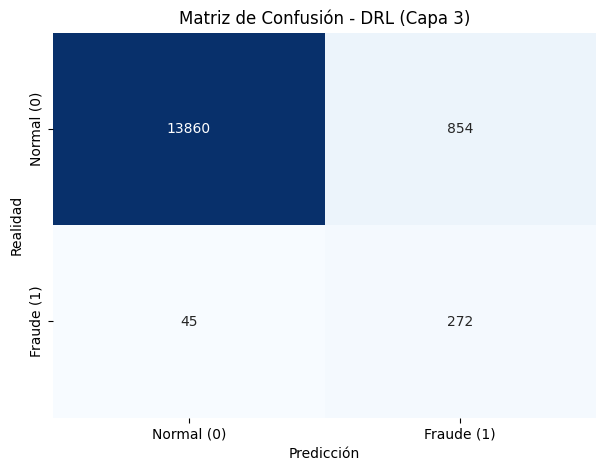

In [ ]:
from sklearn.metrics import recall_score, f1_score, matthews_corrcoef, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. MÉTRICAS FINALES
rec_drl = recall_score(y_test, y_pred_drl)
f1_drl = f1_score(y_test, y_pred_drl)
mcc_drl = matthews_corrcoef(y_test, y_pred_drl)
cm_drl = confusion_matrix(y_test, y_pred_drl)

print("-" * 50)
print("🏆 RESULTADOS FINALES DE DRL (PISO 3 - VALIDACIÓN):")
print("-" * 50)
print(f"🔸 Recall (Fraudes mitigados): {rec_drl:.2%}")
print(f"🔸 F1-Score: {f1_drl:.4f}")
print(f"🔸 MCC: {mcc_drl:.4f}")
print("-" * 50)

# 2. IMPACTO EN EL NEGOCIO (Matriz)
print("\n🚨 IMPACTO EN EL NEGOCIO (DRL):")
print(f"✔️ Clientes sanos permitidos (TN): {cm_drl[0][0]}")
print(f"⚠️ Falsos Positivos (FP): {cm_drl[0][1]}")
print(f"❌ Falsos Negativos (FN): {cm_drl[1][0]}")
print(f"🎯 FRAUDES DETECTADOS (TP): {cm_drl[1][1]}")

# 3. VISUALIZACIÓN
plt.figure(figsize=(7, 5))
sns.heatmap(cm_drl, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'Fraude (1)'],
            yticklabels=['Normal (0)', 'Fraude (1)'])
plt.title('Matriz de Confusión - DRL (Capa 3)')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

In [ ]:
# ==============================================================================
# EVALUACIÓN FINAL DRL: SOBRE EL 20% REAL DE LOS DATOS (SIN MUESTREO)
# ==============================================================================
print("🚀 1. Cargando el conjunto de prueba REAL (20% del total)...")

# Asegúrate de haber definido X_test y y_test en tu bloque anterior de entrenamiento
# (Si no, cárgalos de nuevo tal como en el XGBoost)
# X_test, y_test = ...

print(f"   🔸 Evaluando con {len(X_test)} registros (Conjunto de Test real).")

# 2. EVALUACIÓN POR LOTES (La clave para la RAM)
acciones_drl = []
lote = 5000  # Evaluamos bloques pequeños para no saturar los 42GB de RAM
for i in range(0, len(X_test), lote):
    lote_X = X_test[i:i + lote]
    # Usamos deterministic=True para que no haya aleatoriedad en la prueba
    acc, _ = model_drl.predict(lote_X, deterministic=True)
    acciones_drl.append(acc)

acciones_drl = np.concatenate(acciones_drl)
y_pred_drl = (acciones_drl > 0).astype(int)

# 3. MÉTRICAS COMPARABLES
from sklearn.metrics import recall_score, f1_score, matthews_corrcoef, confusion_matrix

rec_drl = recall_score(y_test, y_pred_drl)
f1_drl = f1_score(y_test, y_pred_drl)
mcc_drl = matthews_corrcoef(y_test, y_pred_drl)
cm_drl = confusion_matrix(y_test, y_pred_drl)

print("-" * 50)
print("🏆 RESULTADOS FINALES DRL (SOBRE 20% REAL):")
print("-" * 50)
print(f"🔸 Recall (Fraudes mitigados): {rec_drl:.2%}")
print(f"🔸 F1-Score: {f1_drl:.4f}")
print(f"🔸 MCC: {mcc_drl:.4f}")
print("-" * 50)

print("\n🚨 IMPACTO EN EL NEGOCIO (DRL):")
print(f"✔️ Clientes sanos permitidos (TN): {cm_drl[0][0]}")
print(f"⚠️ Falsos Positivos (FP): {cm_drl[0][1]}")
print(f"❌ Falsos Negativos (Fugas/FN): {cm_drl[1][0]}")
print(f"🎯 FRAUDES DETECTADOS (TP): {cm_drl[1][1]}")